--- Clean DataFrame with Target Variable Added ---
  student_name  hours_studied  previous_score  attendance  sleep_hours  \
0        Alice            5.0              65        80.0          7.5   
1          Bob            8.0              85        90.0          8.0   
2      Charlie            3.0              55        70.0          6.0   
3        Diana           10.0              92        95.0          9.0   
4          Eve            NaN              75         NaN          NaN   

  extracurricular parent_education  final_score  
0             Yes         Bachelor         80.0  
1              No           Master         97.5  
2             Yes      High School         67.0  
3             Yes              PhD        100.0  
4              No         Bachelor         89.8  


C:\Users\taman\AppData\Local\Temp\ipykernel_9900\1923106557.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='extracurricular', y='final_score', data=df, ax=axes[1, 1], palette='Set2')
C:\Users\taman\AppData\Local\Temp\ipykernel_9900\1923106557.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='parent_education', y='final_score', data=df, order=education_order, ax=axes[1, 2], palette='Pastel1')


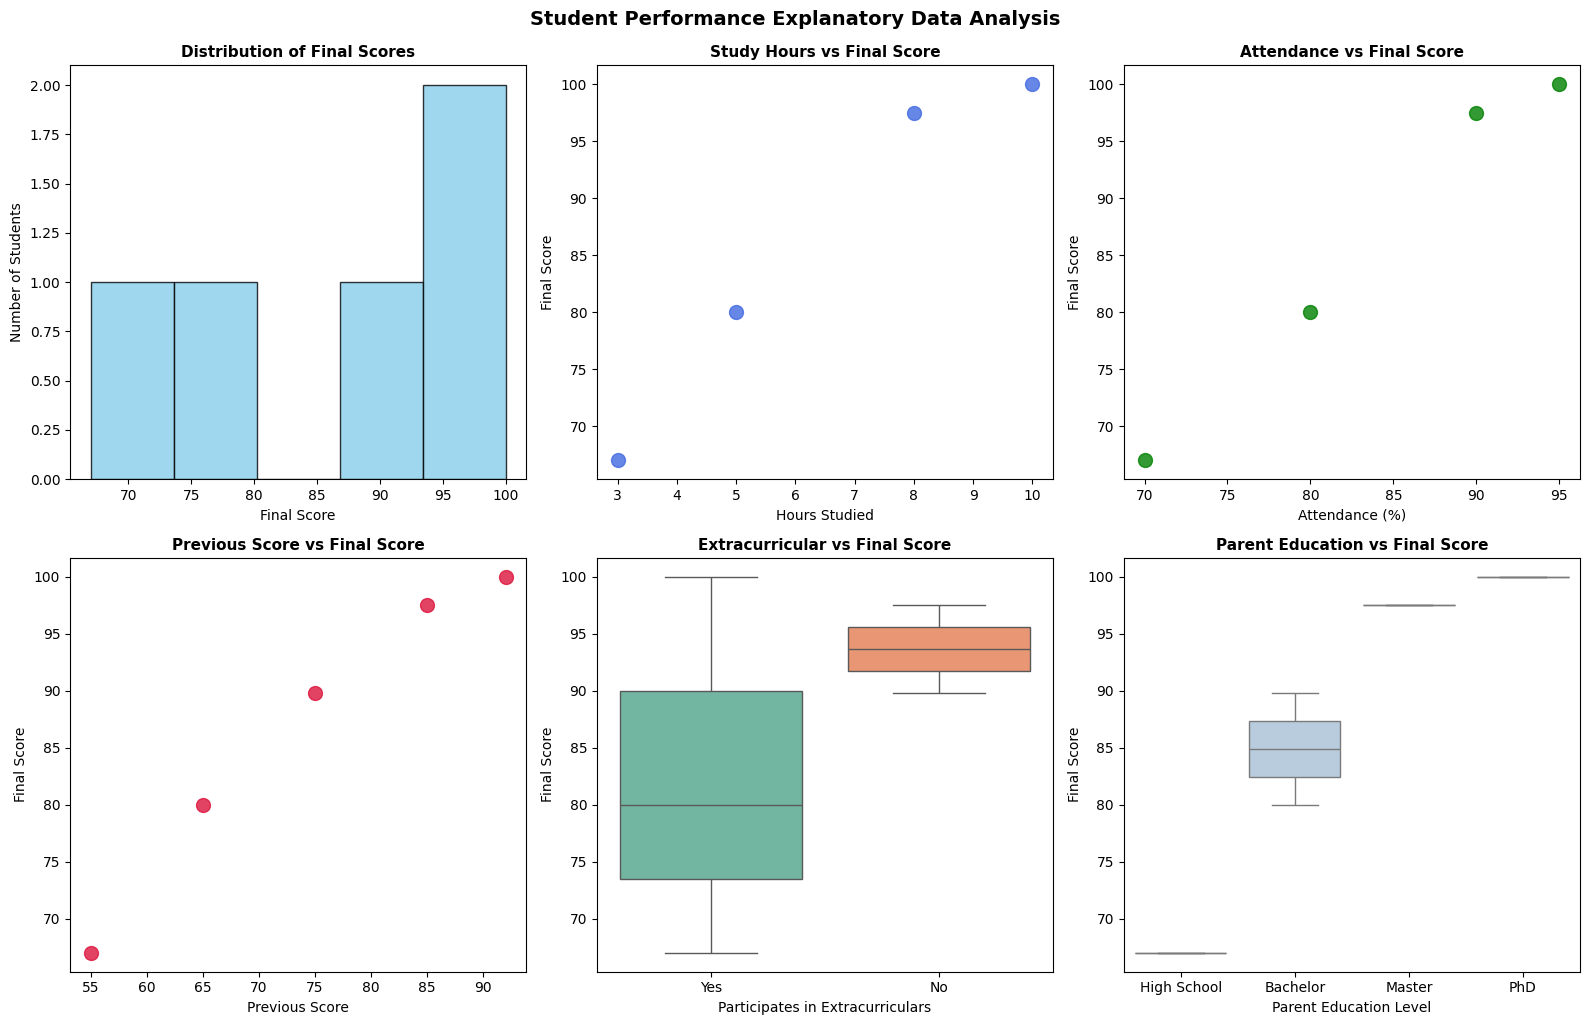

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: Creating the Base DataFrame
# ==========================================
data = {
    'student_name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'hours_studied': [5, 8, 3, 10, None],
    'previous_score': [65, 85, 55, 92, 75],
    'attendance': [80, 90, 70, 95, np.nan],
    'sleep_hours': [7.5, 8.0, 6.0, 9.0, None],
    'extracurricular': ['Yes', 'No', 'Yes', 'Yes', 'No'],
    'parent_education': ['Bachelor', 'Master', 'High School', 'PhD', 'Bachelor']
}

df = pd.DataFrame(data)

# ==========================================
# STEP 2: Feature Engineering (Fixes KeyError: 'final_score')
# ==========================================
# We dynamically fill missing values for calculation, scale features, and cap at 100%
np.random.seed(42)
calculated_score = (
    df['hours_studied'].fillna(df['hours_studied'].mean()) * 3.5 + 
    df['attendance'].fillna(df['attendance'].mean()) * 0.4 + 
    df['previous_score'] * 0.3 + 
    np.random.randint(5, 15, size=len(df))
)
df['final_score'] = np.clip(calculated_score, 0, 100).round(1)

print("--- Clean DataFrame with Target Variable Added ---")
print(df)

# ==========================================
# STEP 3: Data Visualization Grid (2x3)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Distribution of final scores
axes[0, 0].hist(df['final_score'], bins=5, edgecolor='black', color='skyblue', alpha=0.8)
axes[0, 0].set_title('Distribution of Final Scores', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Final Score')
axes[0, 0].set_ylabel('Number of Students')

# 2. Study hours vs Final Score
axes[0, 1].scatter(df['hours_studied'], df['final_score'], s=100, color='royalblue', alpha=0.8)
axes[0, 1].set_title('Study Hours vs Final Score', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Hours Studied')
axes[0, 1].set_ylabel('Final Score')

# 3. Attendance vs Final Score
axes[0, 2].scatter(df['attendance'], df['final_score'], s=100, color='green', alpha=0.8)
axes[0, 2].set_title('Attendance vs Final Score', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('Attendance (%)')
axes[0, 2].set_ylabel('Final Score')

# 4. Previous Score vs Final Score
axes[1, 0].scatter(df['previous_score'], df['final_score'], s=100, color='crimson', alpha=0.8)
axes[1, 0].set_title('Previous Score vs Final Score', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Previous Score')
axes[1, 0].set_ylabel('Final Score')

# 5. Box plot - Extracurricular vs Final Score (Seaborn approach prevents duplicate labels)
sns.boxplot(x='extracurricular', y='final_score', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Extracurricular vs Final Score', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Participates in Extracurriculars')
axes[1, 1].set_ylabel('Final Score')

# 6. Parent Education vs Final Score
education_order = ['High School', 'Bachelor', 'Master', 'PhD']
sns.boxplot(x='parent_education', y='final_score', data=df, order=education_order, ax=axes[1, 2], palette='Pastel1')
axes[1, 2].set_title('Parent Education vs Final Score', fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel('Parent Education Level')
axes[1, 2].set_ylabel('Final Score')

# Tight layout is executed first so it doesn't smash down onto the super title
plt.tight_layout()
plt.suptitle('Student Performance Explanatory Data Analysis', fontsize=14, fontweight='bold', y=1.02)

# Render charts
plt.show()

In [1]:
print("Hello")

Hello
